# Hierarchical Kmeans clustering

# Clustering Parameter Sweep
Tests combinations of hierarchical k-means parameters using **ResNet-50 embeddings**.

For each parameter combination we compute:
- **KL divergence from uniform** — how balanced are the resulting cluster sizes? (lower = more uniform = better)
- **Davies-Bouldin index** — are the clusters geometrically compact and well-separated? (lower = better)

Both metrics are computed on the **fine-level** (most granular) cluster assignment, which is what hierarchical sampling actually draws from.

In [1]:
import os
import sys
import subprocess
import random
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import davies_bouldin_score
from transformers import AutoImageProcessor, AutoModel

import matplotlib.pyplot as plt
import seaborn as sns

# ── paths ────────────────────────────────────────────────────────────────────
IMAGENET_TRAIN_DIR = "/Users/lila/WB_Projekt/WB2_Project/places365/train"
REPO_NAME          = "ssl-data-curation"

# ── dataset config (must match your main experiment) ─────────────────────────
# SELECTED_SYNSETS = [
#     "n01440764", "n02102040", "n02979186", "n03000684", "n03028079",
#     "n03394916", "n03417042", "n03425413", "n03445777", "n03888257",
# ]

SELECTED_SYNSETS = [
    "airport_terminal", "beach", "bedroom", "canyon", "classroom",
    "forest_path", "kitchen", "mountain", "office", "restaurant"
]
NUM_CLASSES      = len(SELECTED_SYNSETS)
TARGET_TRAIN_SIZE = 16267
ALPHA            = 1.0     # Dirichlet skew
SEED             = 42
EMBEDDINGS       = "dino"  # "resnet" or "dino"
DINO_MODEL        = "facebook/dinov2-base"

# ── device ───────────────────────────────────────────────────────────────────
# Before
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# After
if torch.cuda.is_available():    device = torch.device("cuda")
elif torch.backends.mps.is_available(): device = torch.device("mps")
else:                            device = torch.device("cpu")
print(f"Using device: {device}")

/Users/lila/WB_Projekt/WB2_Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 1. Reproducibility & repo setup

In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)

# Clone ssl-data-curation if not already present
if not os.path.exists(REPO_NAME):
    subprocess.run(
        ["git", "clone", "https://github.com/facebookresearch/ssl-data-curation.git"],
        check=True,
    )
sys.path.insert(0, os.path.abspath(REPO_NAME))

from src.clusters import HierarchicalCluster
import src.hierarchical_kmeans_gpu as hkmg

print("ssl-data-curation repo ready.")

ssl-data-curation repo ready.


In [3]:
# Add this right after the git clone cell, before imports
from pathlib import Path
kmeans_gpu_path = Path(REPO_NAME) / "src" / "kmeans_gpu.py"
text = kmeans_gpu_path.read_text()
kmeans_gpu_path.write_text(text.replace("np.Inf", "np.inf"))
print("Patched.")

Patched.


## 2. Build skewed training subset

In [4]:
# def build_skewed_train_dataset(imagenet_train_dir, synsets, target_size, alpha, seed, transform):
#     """Dirichlet-skewed subset — same logic as the main experiment script."""
#     rng = np.random.default_rng(seed)
#     full_ds = datasets.ImageFolder(imagenet_train_dir, transform=transform)
#     class_to_idx = full_ds.class_to_idx

#     synset_indices = {s: class_to_idx[s] for s in synsets if s in class_to_idx}
#     if len(synset_indices) < len(synsets):
#         missing = set(synsets) - set(synset_indices)
#         raise ValueError(f"Synsets not found: {missing}")

#     idx_by_class = {v: [] for v in synset_indices.values()}
#     for sample_idx, (_, label) in enumerate(full_ds.samples):
#         if label in idx_by_class:
#             idx_by_class[label].append(sample_idx)

#     proportions = rng.dirichlet(alpha=np.full(NUM_CLASSES, alpha))
#     counts = {
#         cls_idx: min(max(1, round(prop * target_size)), len(idx_by_class[cls_idx]))
#         for cls_idx, prop in zip(idx_by_class.keys(), proportions)
#     }

#     selected = []
#     for cls_idx, n in counts.items():
#         chosen = rng.choice(idx_by_class[cls_idx], size=n, replace=False).tolist()
#         selected.extend(chosen)

#     actual_total = sum(counts.values())
#     print(f"Dataset built — alpha={alpha}, "
#           f"min={min(counts.values())}, max={max(counts.values())}, total={actual_total}")
#     return Subset(full_ds, selected)


res_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# skewed_ds = build_skewed_train_dataset(
#     IMAGENET_TRAIN_DIR, SELECTED_SYNSETS, TARGET_TRAIN_SIZE, ALPHA, SEED, res_transform
# )

In [5]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

def load_dataset(data_dir="places365/train", batch_size=32, img_size=(224, 224)):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = ImageFolder(root=data_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    
    return dataset, dataloader

# Usage:
skewed_ds, dataloader = load_dataset("data/skewed_places365_alpha1/train")
print(skewed_ds.classes) # ['airport_terminal', 'beach', ...]

['airport_terminal', 'beach', 'bedroom', 'canyon', 'classroom', 'forest_path', 'kitchen', 'mountain', 'office', 'restaurant']


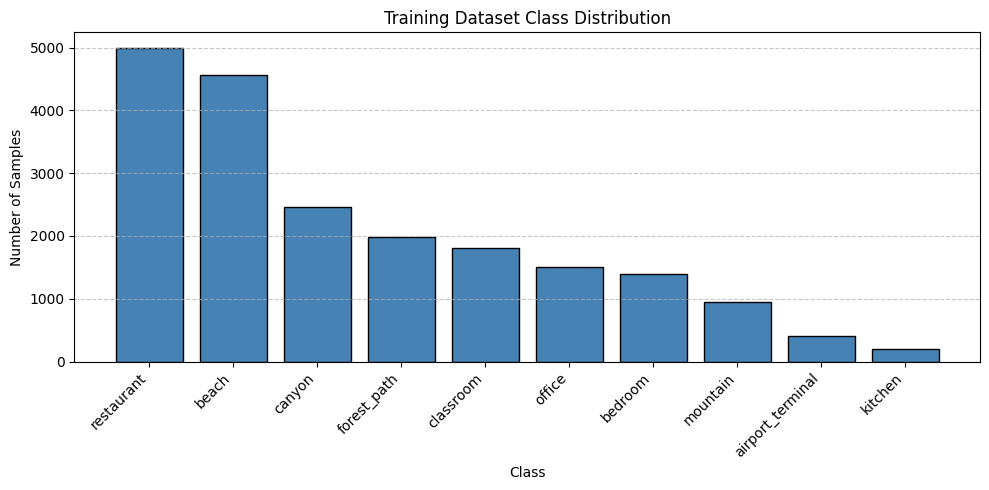

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ImageFolder exposes labels directly via the .targets attribute
labels = skewed_ds.targets

unique_classes, counts = np.unique(labels, return_counts=True)

sorted_idx = np.argsort(-counts)
counts_sorted = counts[sorted_idx]
classes_sorted = unique_classes[sorted_idx]

# Map numeric indices back to actual class names
class_names_sorted = [skewed_ds.classes[c] for c in classes_sorted]

plt.figure(figsize=(10, 5))
plt.bar(range(len(counts_sorted)), counts_sorted, color="steelblue", edgecolor="black")

plt.xticks(
    range(len(counts_sorted)), 
    class_names_sorted, 
    rotation=45, 
    ha="right"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Extract ResNet-50 embeddings
We use the output of the `avgpool` layer (before the final FC) — a 2048-d vector per image.
The backbone is frozen; we just extract features.

In [7]:
import torch.nn.functional as F

def get_resnet_embeddings(dataset, device) -> torch.Tensor:
    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    backbone.fc = nn.Identity()
    backbone = backbone.to(device)
    backbone.eval()

    loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    features = []

    with torch.inference_mode():
        for imgs, _ in tqdm(loader, desc="ResNet embeddings"):
            out = backbone(imgs.to(device))
            features.append(out.cpu())

    embeddings = torch.cat(features)
    return F.normalize(embeddings, p=2, dim=1)

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from transformers import AutoModel
from tqdm import tqdm

def get_dino_embeddings(dataset, model_name, device) -> torch.Tensor:
    print(f"\n  STEP 1: SSL feature extraction ({model_name})")
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    inner = dataset.dataset if isinstance(dataset, Subset) else dataset
    original_transform = inner.transform

    inner.transform = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    loader = DataLoader(
        dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )
    
    features = []
    device_type = "cuda" if "cuda" in str(device) else "mps" if "mps" in str(device) else "cpu"

    with torch.inference_mode(), torch.autocast(device_type=device_type):
        for imgs, _ in tqdm(loader, desc="  DINO"):
            out = model(imgs.to(device))
            features.append(out.last_hidden_state[:, 0, :].cpu().float())

    inner.transform = original_transform
    embeddings = torch.cat(features)
    return F.normalize(embeddings, p=2, dim=1)

# if EMBEDDINGS == "resnet":
#     embeddings = get_resnet_embeddings(skewed_ds, device)
# else:
#     # Pass the DINO_MODEL string and the device variable
#     embeddings = get_dino_embeddings(skewed_ds, DINO_MODEL, device)

In [8]:
# # Save to disk
# torch.save(embeddings, f"dino_embeddings{ALPHA}_places365.pt")
# print("Embeddings saved successfully.")

In [9]:
embeddings = torch.load(f"dino_embeddings{ALPHA}_places365.pt", map_location="cpu", weights_only=True)
embeddings_np = embeddings.numpy()
embeddings = embeddings.to(device="mps", dtype=torch.float32)

## 4. Metric helpers

### KL divergence from uniform
Measures how far the cluster-size distribution is from a perfectly uniform one.
Computed on the **finest** level of the hierarchy (where sampling actually happens).

$$KL(P \| U) = \sum_i p_i \log\left(p_i \cdot K\right)$$

→ 0 means perfectly uniform; higher means more skewed.

### Davies-Bouldin index
For each cluster, measures the ratio of (within-cluster scatter) to (between-cluster distance), then averages the worst-case ratio over all clusters.  
→ Lower is better (compact, well-separated clusters).

In [10]:
def get_fine_level_labels(cl: HierarchicalCluster, n_samples: int) -> np.ndarray:
    """Return per-sample cluster labels at the finest (lowest-key) hierarchy level."""
    fine_level = min(cl.clusters.keys())
    fine_clusters = cl.clusters[fine_level]
    labels = np.full(n_samples, -1, dtype=int)
    for cluster_id, indices in enumerate(fine_clusters):
        labels[np.asarray(indices)] = cluster_id
    # Assign any unlabelled points to an overflow cluster
    if (labels == -1).any():
        labels[labels == -1] = len(fine_clusters)
    return labels


def kl_from_uniform(labels: np.ndarray, target_k: int) -> float:
    counts = np.bincount(labels, minlength=target_k).astype(float)
    p = np.clip(counts / counts.sum(), 1e-9, None)
    p = p / p.sum()
    uniform = np.ones(target_k) / target_k
    return float(scipy_entropy(p, uniform))


def davies_bouldin(embeddings_np: np.ndarray, labels: np.ndarray) -> float:
    """Davies-Bouldin index. Needs at least 2 non-empty clusters."""
    # DB score requires embeddings and integer cluster labels
    return float(davies_bouldin_score(embeddings_np, labels))


print("Metric helpers defined.")

Metric helpers defined.


## 5. Parameter grid

We sweep over:
- **`n_clusters`** — number of clusters at each level (finest → coarsest)
- **`sample_sizes`** — how many samples are drawn per cluster at each level during the resampling step

`n_levels` is derived from the length of `n_clusters`.

In [11]:
PARAM_GRID = [
    # ── Fix 1: sample_sizes scaled to actual cluster size ──────────────────
    # With 16k samples / 150 fine clusters = ~108 avg size
    # sample_size should be >= avg cluster size to actually resample effectively
    ([150, 50, 10], [110, 325, 1600], 20),
    ([150, 50, 10], [110, 325, 1600], 40),
    ([100, 30, 10], [160, 540, 1600], 20),
    ([100, 30, 10], [160, 540, 1600], 40),

    # ── Fix 2: smaller fine level to reduce over-segmentation ───────────────
    # 50-60 fine clusters for 16k samples = ~270-320 avg size, more coherent
    ([60, 20, 10],  [270, 800, 1600], 20),
    ([60, 20, 10],  [270, 800, 1600], 40),
    ([50, 15, 10],  [325, 1000, 1600], 20),
    ([50, 15, 10],  [325, 1000, 1600], 40),

    # ── Fix 3: don't force coarse K=10, let it be K=15-20 ──────────────────
    # Your 10 classes have substructure (indoor vs outdoor beach etc.)
    ([100, 30, 15], [160, 540, 1000], 20),
    ([100, 30, 20], [160, 540, 800],  20),
    ([60,  20, 15], [270, 800, 1000], 20),
    ([60,  20, 15], [270, 800, 1000], 40),

    # ── Fix 4: high resamples on shallow configs for imbalanced data ────────
    ([80, 10],  [200, 1600], 50),
    ([60, 10],  [270, 1600], 50),
    ([50, 10],  [325, 1600], 50),
    ([40, 10],  [400, 1600], 50),

    # ── Fix 5: 4-level with correct sample sizing ───────────────────────────
    ([200, 80, 25, 10], [80,  200, 650, 1600], 20),
    ([150, 60, 20, 10], [110, 270, 800, 1600], 20),
    ([100, 40, 15, 10], [160, 400, 1000, 1600], 30),
]
print(f"Grid size: {len(PARAM_GRID)} configurations")

Grid size: 19 configurations


## 6. Run the sweep

In [12]:
# Pre-convert embeddings to numpy once — reused for DB score every iteration
embeddings_np = embeddings.cpu().numpy()

results = []


for n_clusters, sample_sizes, n_resamples in tqdm(PARAM_GRID, desc="Parameter sweep"):
    n_levels = len(n_clusters)
    label = f"nc={n_clusters} ss={sample_sizes} nr={n_resamples}"
    print(f"\n── {label}")

    # ...
    try:
        set_seed(SEED)

        clusters_dict = hkmg.hierarchical_kmeans_with_resampling(
            data=embeddings.cpu().float(),
            n_clusters=n_clusters,
            n_levels=n_levels,
            sample_sizes=sample_sizes,
            n_resamples=n_resamples,
            verbose=False,
        )
        cl = HierarchicalCluster.from_dict(clusters_dict)

        fine_labels = get_fine_level_labels(cl, len(skewed_ds))
        n_nonempty  = len(np.unique(fine_labels))

        kl = kl_from_uniform(fine_labels, n_clusters[0])
        db = davies_bouldin(embeddings_np, fine_labels)

        print(f"   KL={kl:.4f}  DB={db:.4f}  non-empty clusters={n_nonempty}/{n_clusters[0]}")
# ...

        results.append(dict(
            n_clusters=str(n_clusters),
            sample_sizes=str(sample_sizes),
            n_resamples=n_resamples,
            n_levels=n_levels,
            fine_k=n_clusters[0],
            coarse_k=n_clusters[-1],
            n_nonempty=n_nonempty,
            kl_divergence=round(kl, 6),
            davies_bouldin=round(db, 6),
        ))

    except Exception as e:
        print(f"   FAILED: {e}")
        results.append(dict(
            n_clusters=str(n_clusters), sample_sizes=str(sample_sizes), n_resamples=n_resamples,
            n_levels=n_levels, fine_k=n_clusters[0], coarse_k=n_clusters[-1],
            n_nonempty=None, kl_divergence=None, davies_bouldin=None,
        ))

df = pd.DataFrame(results)
df

Parameter sweep:   0%|          | 0/19 [00:00<?, ?it/s]


── nc=[150, 50, 10] ss=[110, 325, 1600] nr=20
Hierarchical k-means resampling steps: 100%|██████████| 20/20 [00:00<00:00, 22.37it/s]


Parameter sweep:   5%|▌         | 1/19 [01:34<28:14, 94.16s/it]

   KL=0.1311  DB=3.4332  non-empty clusters=150/150

── nc=[150, 50, 10] ss=[110, 325, 1600] nr=40
Hierarchical k-means resampling steps: 100%|██████████| 40/40 [00:01<00:00, 33.68it/s]


Parameter sweep:  11%|█         | 2/19 [04:01<35:33, 125.50s/it]

...

Parameter sweep:  95%|█████████▍| 18/19 [50:46<03:59, 239.86s/it]

   KL=0.1311  DB=3.4332  non-empty clusters=150/150

── nc=[100, 40, 15, 10] ss=[160, 400, 1000, 1600] nr=30
Hierarchical k-means resampling steps: 100%|██████████| 30/30 [00:01<00:00, 24.34it/s]


Parameter sweep: 100%|██████████| 19/19 [53:37<00:00, 169.33s/it]

   KL=0.1188  DB=3.5100  non-empty clusters=100/100


,n_clusters,sample_sizes,n_resamples,n_levels,fine_k,coarse_k,n_nonempty,kl_divergence,davies_bouldin
0,"[150, 50, 10]","[110, 325, 1600]",20,3,150,10,150,0.131143,3.433245
1,"[150, 50, 10]","[110, 325, 1600]",40,3,150,10,150,0.143064,3.391229
2,"[100, 30, 10]","[160, 540, 1600]",20,3,100,10,100,0.142020,3.454231
3,"[100, 30, 10]","[160, 540, 1600]",40,3,100,10,100,0.116130,3.449560
4,"[60, 20, 10]","[270, 800, 1600]",20,3,60,10,60,0.093243,3.661145
5,"[60, 20, 10]","[270, 800, 1600]",40,3,60,10,60,0.102154,3.559554
6,"[50, 15, 10]","[325, 1000, 1600]",20,3,50,10,50,0.140787,3.557835
7,"[50, 15, 10]","[325, 1000, 1600]",40,3,50,10,50,0.095243,3.568842
8,"[100, 30, 15]","[160, 540, 1000]",20,3,100,15,100,0.142020,3.454231
9,"[100, 30, 20]","[160, 540, 800]",20,3,100,20,100,0.142020,3.454231


## 7. Results table — ranked by KL divergence

In [28]:
df_clean = df.dropna(subset=["kl_divergence", "davies_bouldin"]).copy()

# Normalise both metrics to [0, 1] so we can compute a combined rank
df_clean["kl_norm"] = (df_clean["kl_divergence"] - df_clean["kl_divergence"].min()) / \
                      (df_clean["kl_divergence"].max() - df_clean["kl_divergence"].min() + 1e-9)

df_clean["db_norm"] = (df_clean["davies_bouldin"] - df_clean["davies_bouldin"].min()) / \
                      (df_clean["davies_bouldin"].max() - df_clean["davies_bouldin"].min() + 1e-9)

# Combined score — equal weight; lower is better for both
df_clean["combined_score"] = 0.5 * df_clean["kl_norm"] + 0.5 * df_clean["db_norm"]

df_ranked = df_clean.sort_values("combined_score").reset_index(drop=True)
df_ranked[["n_clusters", "sample_sizes", "n_nonempty",
           "kl_divergence", "davies_bouldin", "combined_score"]]

,n_clusters,sample_sizes,n_nonempty,kl_divergence,davies_bouldin,combined_score
0,"[100, 30, 10]","[160, 540, 1600]",100,0.116130,3.449560,0.292152
1,"[40, 10]","[400, 1600]",40,0.091767,3.570101,0.316754
2,"[80, 10]","[200, 1600]",80,0.094366,3.568420,0.330256
3,"[50, 15, 10]","[325, 1000, 1600]",50,0.095243,3.568842,0.336239
4,"[150, 50, 10]","[110, 325, 1600]",150,0.131143,3.433245,0.360617
5,"[150, 60, 20, 10]","[110, 270, 800, 1600]",150,0.131143,3.433245,0.360617
6,"[60, 20, 10]","[270, 800, 1600]",60,0.102154,3.559554,0.365192
7,"[60, 20, 15]","[270, 800, 1000]",60,0.102154,3.559554,0.365192
8,"[150, 50, 10]","[110, 325, 1600]",150,0.143064,3.391229,0.373056
9,"[100, 40, 15, 10]","[160, 400, 1000, 1600]",100,0.118752,3.510036,0.395468


In [29]:
# Save full results
df_ranked.to_csv("clustering_sweep_results.csv", index=False)
print("Saved → clustering_sweep_results.csv")

best = df_ranked.iloc[0]
print(f"\nBest configuration:")
print(f"  n_clusters   = {best['n_clusters']}")
print(f"  sample_sizes = {best['sample_sizes']}")
print(f"  KL divergence  = {best['kl_divergence']:.4f}")
print(f"  Davies-Bouldin = {best['davies_bouldin']:.4f}")

Saved → clustering_sweep_results.csv

Best configuration:
  n_clusters   = [100, 30, 10]
  sample_sizes = [160, 540, 1600]
  KL divergence  = 0.1161
  Davies-Bouldin = 3.4496


## 8. Visualisation

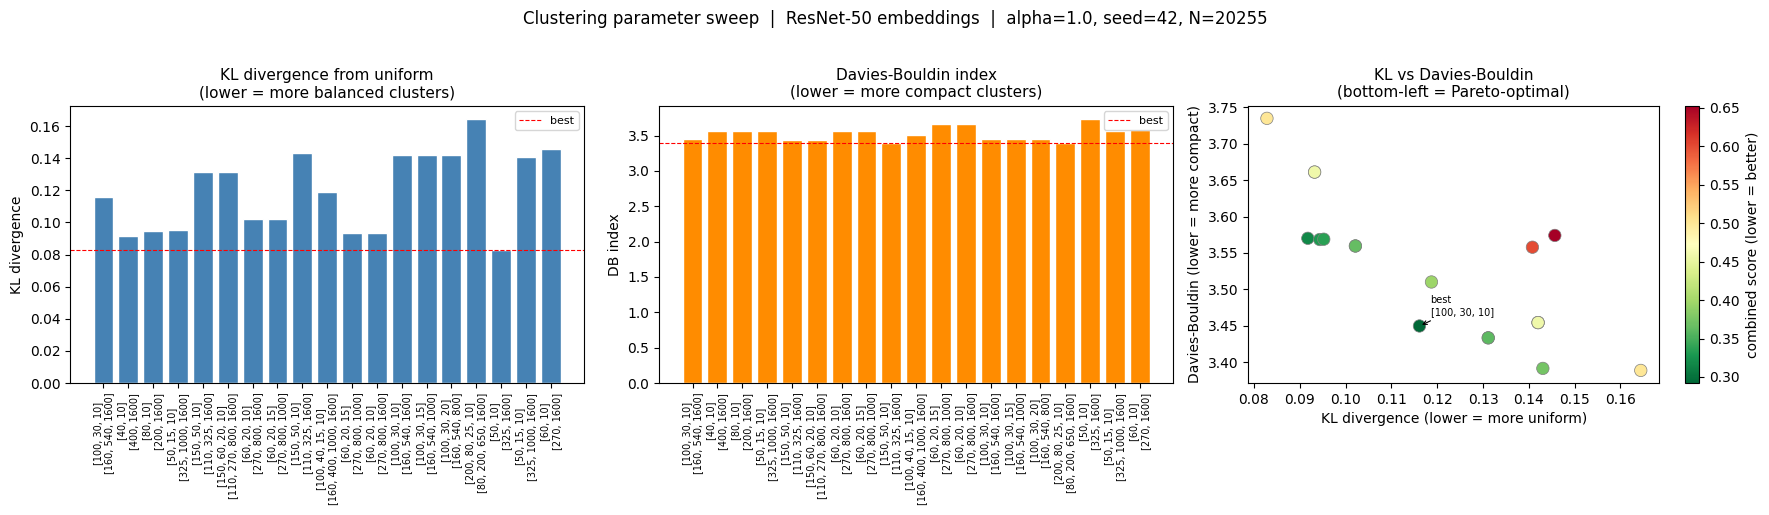

Saved → clustering_sweep.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = [f"{r['n_clusters']}\n{r['sample_sizes']}" for _, r in df_ranked.iterrows()]
x = np.arange(len(df_ranked))

# ── KL divergence ────────────────────────────────────────────────────────────
axes[0].bar(x, df_ranked["kl_divergence"], color="steelblue", edgecolor="white")
axes[0].set_title("KL divergence from uniform\n(lower = more balanced clusters)", fontsize=11)
axes[0].set_ylabel("KL divergence")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=90, fontsize=7)
axes[0].axhline(df_ranked["kl_divergence"].min(), color="red", linestyle="--", linewidth=0.8, label="best")
axes[0].legend(fontsize=8)

# ── Davies-Bouldin ───────────────────────────────────────────────────────────
axes[1].bar(x, df_ranked["davies_bouldin"], color="darkorange", edgecolor="white")
axes[1].set_title("Davies-Bouldin index\n(lower = more compact clusters)", fontsize=11)
axes[1].set_ylabel("DB index")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=90, fontsize=7)
axes[1].axhline(df_ranked["davies_bouldin"].min(), color="red", linestyle="--", linewidth=0.8, label="best")
axes[1].legend(fontsize=8)

# ── Scatter: KL vs DB ────────────────────────────────────────────────────────
sc = axes[2].scatter(
    df_ranked["kl_divergence"],
    df_ranked["davies_bouldin"],
    c=df_ranked["combined_score"],
    cmap="RdYlGn_r",
    s=80, edgecolors="gray", linewidths=0.5,
)
# Annotate the best point
axes[2].annotate(
    f"best\n{best['n_clusters']}",
    xy=(best["kl_divergence"], best["davies_bouldin"]),
    xytext=(8, 8), textcoords="offset points", fontsize=7,
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
)
axes[2].set_xlabel("KL divergence (lower = more uniform)")
axes[2].set_ylabel("Davies-Bouldin (lower = more compact)")
axes[2].set_title("KL vs Davies-Bouldin\n(bottom-left = Pareto-optimal)", fontsize=11)
plt.colorbar(sc, ax=axes[2], label="combined score (lower = better)")

plt.suptitle(
    f"Clustering parameter sweep  |  ResNet-50 embeddings  |  "
    f"alpha={ALPHA}, seed={SEED}, N={len(skewed_ds)}",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig("clustering_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → clustering_sweep.png")

## 9. Cluster size distributions for top-3 configurations
Visualises the actual fine-level cluster size histograms to sanity-check that the best-scoring configurations really are more uniform.

Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:00<00:00, 10.66it/s]


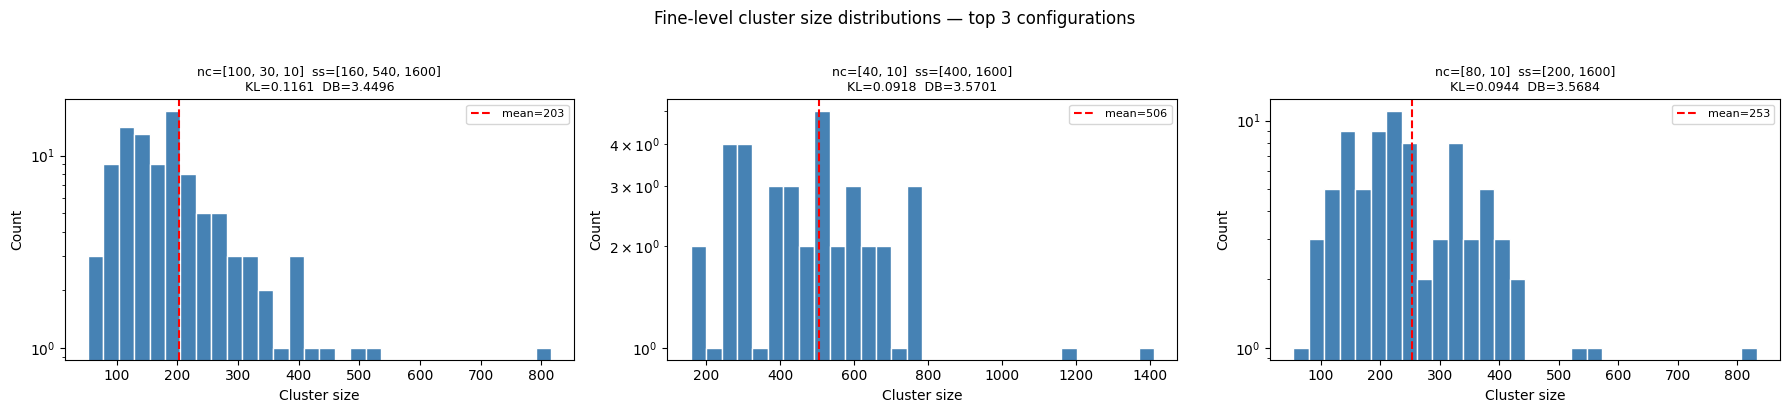

Saved → top3_cluster_sizes.png


In [16]:
top3 = df_ranked.head(3)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (_, row) in zip(axes, top3.iterrows()):
    n_clusters  = eval(row["n_clusters"])
    sample_sizes = eval(row["sample_sizes"])
    set_seed(SEED)

    clusters_dict = hkmg.hierarchical_kmeans_with_resampling(
        data=embeddings.cpu().float(),
        n_clusters=n_clusters,
        n_levels=len(n_clusters),
        sample_sizes=sample_sizes,
        verbose=False,
    )
    cl = HierarchicalCluster.from_dict(clusters_dict)
    fine_labels = get_fine_level_labels(cl, len(skewed_ds))
    sizes = np.bincount(fine_labels)

    ax.hist(sizes, bins=30, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    ax.axvline(sizes.mean(), color="red", linestyle="--", label=f"mean={sizes.mean():.0f}")
    ax.set_title(
        f"nc={n_clusters}  ss={sample_sizes}\n"
        f"KL={row['kl_divergence']:.4f}  DB={row['davies_bouldin']:.4f}",
        fontsize=9,
    )
    ax.set_xlabel("Cluster size")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Fine-level cluster size distributions — top 3 configurations", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("top3_cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → top3_cluster_sizes.png")

In [17]:
try:
    import umap
except ImportError:
    raise ImportError("Install umap-learn:  pip install umap-learn")

SYNSET_NAMES = [
    "airport_terminal", "beach", "bedroom", "canyon", "classroom",
    "forest_path", "kitchen", "mountain", "office", "restaurant"
]



def get_true_labels_for_subset(subset):
    """Remap raw ImageFolder class indices to contiguous 0..K-1."""
    inner = subset.dataset
    raw = np.array([inner.samples[i][1] for i in subset.indices])
    unique = sorted(set(raw.tolist()))
    remap = {old: new for new, old in enumerate(unique)}
    return np.array([remap[v] for v in raw])


def get_coarse_level_labels(cl, n_samples):
    # Map each fine cluster → which coarse cluster it belongs to
    fine_clusters  = cl.clusters[1]   # list of lists of sample indices
    coarse_clusters = cl.clusters[2]  # list of lists of FINE CLUSTER indices

    # Build fine_cluster_id → coarse_id lookup
    fine_to_coarse = {}
    for coarse_id, fine_ids in enumerate(coarse_clusters):
        for fine_id in fine_ids:
            fine_to_coarse[fine_id] = coarse_id

    # Assign each sample its coarse label via its fine cluster
    labels = np.full(n_samples, -1, dtype=int)
    for fine_id, sample_indices in enumerate(fine_clusters):
        coarse_id = fine_to_coarse.get(fine_id, -1)
        for idx in sample_indices:
            labels[idx] = coarse_id

    return labels


def visualize_clusters_umap(embeddings, true_labels, fine_labels, n_clusters, sample_sizes, seed, class_names):
    """
    UMAP projection coloured by true class (left) and fine cluster (right).
    Ported from the main experiment script.
    """
    print(f"UMAP projection for nc={n_clusters} ss={sample_sizes} ...", flush=True)
    reducer = umap.UMAP(n_components=2, random_state=seed, n_jobs=1, verbose=False)
    emb_2d  = reducer.fit_transform(embeddings.cpu().numpy())

    n_classes  = len(class_names)
    n_fine     = int(fine_labels.max()) + 1
    class_cmap = plt.cm.get_cmap("tab10", n_classes)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 6))

    # Left: coloured by true class
    for cls_id in range(n_classes):
        mask = true_labels == cls_id
        ax_l.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=[class_cmap(cls_id)], s=4, alpha=0.6, linewidths=0,
            label=f"{class_names[cls_id]}  (n={mask.sum()})",
        )
    ax_l.set_title("Coloured by true class", fontsize=11)
    ax_l.set_xlabel("UMAP-1"); ax_l.set_ylabel("UMAP-2")
    ax_l.legend(markerscale=3, fontsize=7, loc="best",
                title="class", title_fontsize=8, framealpha=0.7, ncol=2)

    # Right: coloured by fine cluster — use a continuous colormap since K can be large
    sc = ax_r.scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c=fine_labels, cmap="tab20", s=4, alpha=0.6, linewidths=0,
    )
    ax_r.set_title(f"Coloured by fine cluster  (K={n_fine})", fontsize=11)
    ax_r.set_xlabel("UMAP-1")
    plt.colorbar(sc, ax=ax_r, label="cluster id", shrink=0.8)

    fig.suptitle(
        f"ResNet-50 embeddings — best clustering config\n"
        f"nc={n_clusters}  ss={sample_sizes}  |  "
        f"{len(true_labels):,} training samples  |  alpha={ALPHA}",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    fname = "umap_best_config.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")
    return emb_2d


print("UMAP helpers defined.")

UMAP helpers defined.


Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:00<00:00, 20.93it/s]
UMAP projection for nc=[100, 30, 10] ss=[160, 540, 1600] ...


/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_87146/2357799877.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = plt.cm.get_cmap("tab10", n_classes)


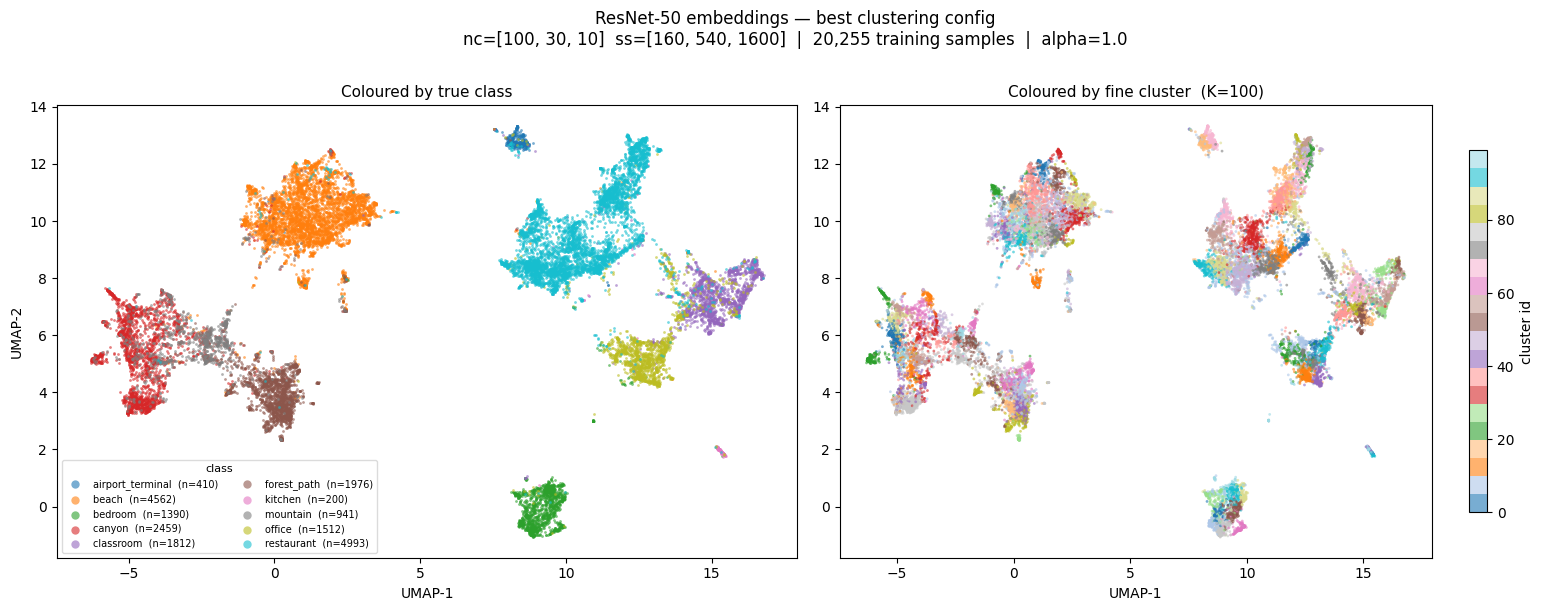

Saved → umap_best_config.png


In [18]:
# Re-run clustering with the best parameters
best_n_clusters   = eval(best["n_clusters"])
best_sample_sizes = eval(best["sample_sizes"])

set_seed(SEED)
clusters_dict = hkmg.hierarchical_kmeans_with_resampling(
    data=embeddings.cpu().float(),
    n_clusters=best_n_clusters,
    n_levels=len(best_n_clusters),
    sample_sizes=best_sample_sizes,
    verbose=False,
)
cl_best = HierarchicalCluster.from_dict(clusters_dict)

true_labels = np.array(skewed_ds.targets)
fine_labels = get_fine_level_labels(cl_best, len(skewed_ds))

emb_2d = visualize_clusters_umap(
    embeddings, true_labels, fine_labels,
    best_n_clusters, best_sample_sizes, SEED, SYNSET_NAMES,
)

In [19]:
def get_coarse_level_labels_fixed(cl, n_samples):
    fine_clusters   = cl.clusters[1]  # sample indices
    coarse_clusters = cl.clusters[2]  # fine cluster indices

    fine_to_coarse = {}
    for coarse_id, fine_ids in enumerate(coarse_clusters):
        for fine_id in fine_ids:
            fine_to_coarse[fine_id] = coarse_id

    labels = np.full(n_samples, -1, dtype=int)
    for fine_id, sample_indices in enumerate(fine_clusters):
        coarse_id = fine_to_coarse.get(fine_id, -1)
        for idx in sample_indices:
            labels[idx] = coarse_id

    return labels

coarse_labels = get_coarse_level_labels_fixed(cl_best, len(skewed_ds))
print("Unique coarse labels:", np.unique(coarse_labels))
print("Coarse label counts:", np.bincount(coarse_labels[coarse_labels >= 0]))
print("Unlabelled samples:", (coarse_labels == -1).sum())

Unique coarse labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
Coarse label counts: [ 301 2535  638  501  466  391 1019  534  701  490  721  390  191  907
  542  571 1096  668 2332  619  535  690 1162  696  258  780  103  105
  192  121]
Unlabelled samples: 0


/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_87146/3926571646.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:00<00:00, 22.69it/s]


/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_87146/3926571646.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  coarse_cmap = plt.cm.get_cmap("Set1", n_coarse)


Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:00<00:00, 14.01it/s]


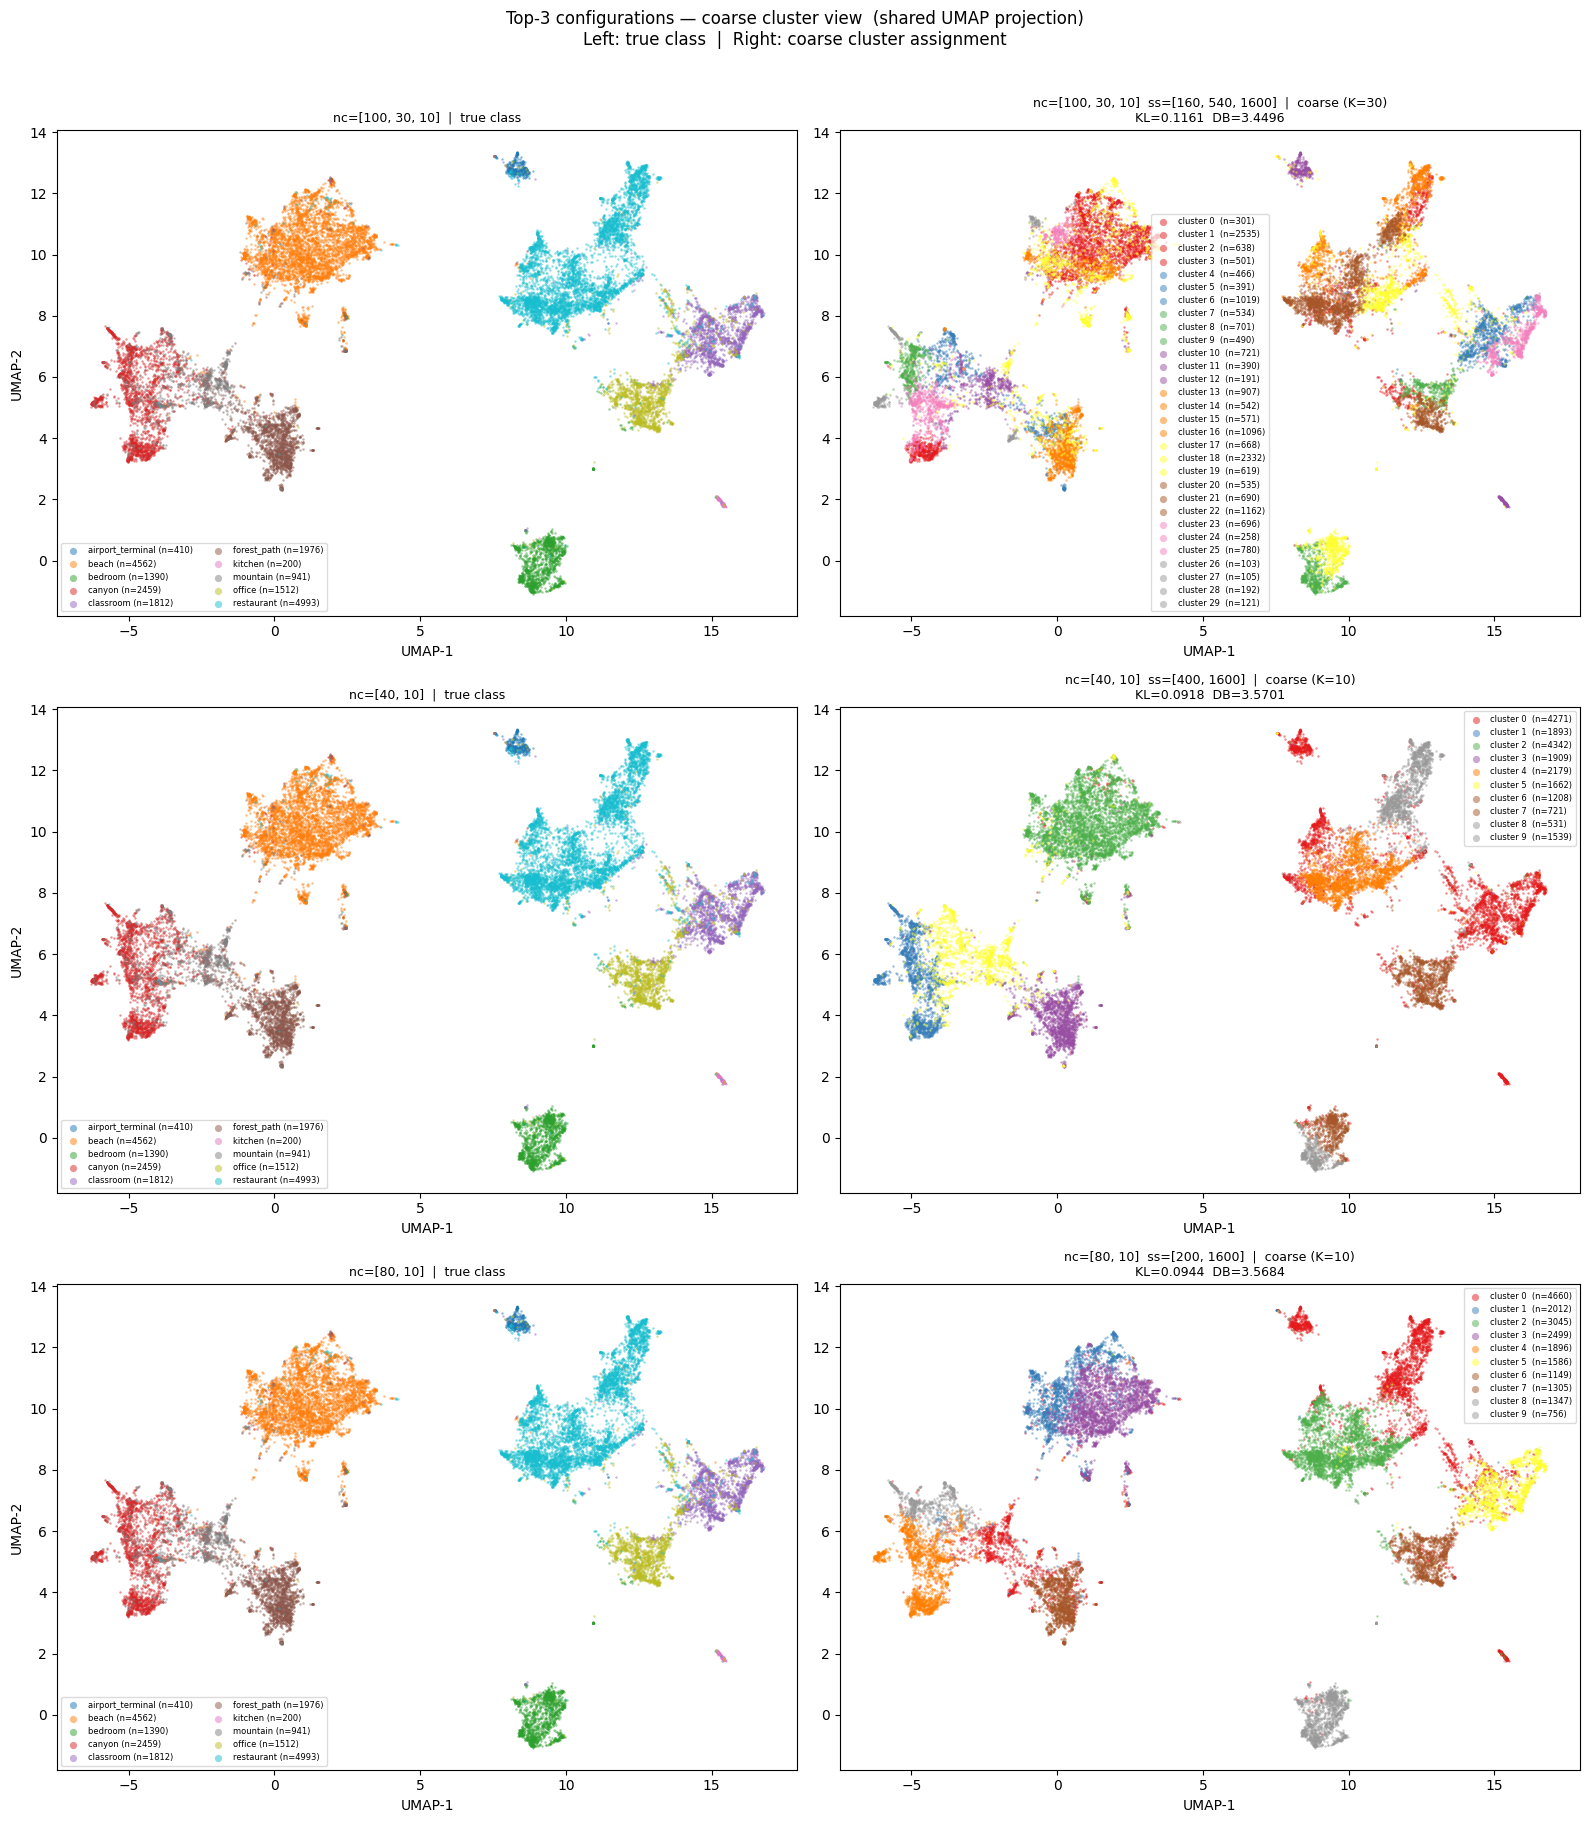

Saved → umap_top3_coarse.png


In [20]:
top3 = df_ranked.head(3)
n_rows = len(top3)
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 6 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

class_cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)

for row_i, (_, row) in enumerate(top3.iterrows()):
    n_clusters_i   = eval(row["n_clusters"])
    sample_sizes_i = eval(row["sample_sizes"])

    set_seed(SEED)
    cd = hkmg.hierarchical_kmeans_with_resampling(
        data=embeddings.cpu().float(),
        n_clusters=n_clusters_i,
        n_levels=len(n_clusters_i),
        sample_sizes=sample_sizes_i,
        verbose=False,
    )
    cl_i = HierarchicalCluster.from_dict(cd)
    coarse_labels_i = get_coarse_level_labels(cl_i, len(skewed_ds))
    n_coarse = int(coarse_labels_i.max()) + 1
    coarse_cmap = plt.cm.get_cmap("Set1", n_coarse)

    ax_l, ax_r = axes[row_i, 0], axes[row_i, 1]

    # Left: true classes
    for cls_id in range(NUM_CLASSES):
        mask = true_labels == cls_id
        ax_l.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                     c=[class_cmap(cls_id)], s=3, alpha=0.5, linewidths=0,
                     label=f"{SYNSET_NAMES[cls_id]} (n={mask.sum()})")
    ax_l.set_title(f"nc={n_clusters_i}  |  true class", fontsize=9)
    ax_l.set_xlabel("UMAP-1"); ax_l.set_ylabel("UMAP-2")
    ax_l.legend(markerscale=3, fontsize=6, loc="best", ncol=2, framealpha=0.7)

    # Right: coarse clusters
    for c_id in range(n_coarse):
        mask = coarse_labels_i == c_id
        ax_r.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                     c=[coarse_cmap(c_id)], s=3, alpha=0.5, linewidths=0,
                     label=f"cluster {c_id}  (n={mask.sum()})")
    ax_r.set_title(
        f"nc={n_clusters_i}  ss={sample_sizes_i}  |  coarse (K={n_coarse})\n"
        f"KL={row['kl_divergence']:.4f}  DB={row['davies_bouldin']:.4f}",
        fontsize=9,
    )
    ax_r.set_xlabel("UMAP-1")
    ax_r.legend(markerscale=3, fontsize=6, loc="best", framealpha=0.7)

fig.suptitle(
    "Top-3 configurations — coarse cluster view  (shared UMAP projection)\n"
    "Left: true class  |  Right: coarse cluster assignment",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig("umap_top3_coarse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → umap_top3_coarse.png")

## 10. Alternative clustering methods — parameter sweep

Runs the same KL / Davies-Bouldin evaluation for **flat KMeans** and **DBSCAN**
using the helpers in `other_clustering_methods.py`.

* **KMeans** sweep: vary `n_clusters` (the number of flat clusters).
* **DBSCAN** sweep: vary `eps` (neighbourhood radius) and `min_samples`.

Both methods use `_sample_from_labels` from the same file so the sampling
logic is identical to hierarchical k-means.

In [21]:
from other_clustering_methods import kmeans_sampling, dbscan_sampling
from sklearn.cluster import KMeans, DBSCAN

embeddings_np = embeddings.cpu().numpy()   # already computed above

# ── KMeans parameter grid ─────────────────────────────────────────────────────
KMEANS_N_CLUSTERS = [10, 20, 50, 100, 150, 200]

kmeans_results = []
for k in KMEANS_N_CLUSTERS:
    set_seed(SEED)
    km = KMeans(n_clusters=k, n_init="auto", random_state=SEED).fit(embeddings_np)
    labels = km.labels_
    n_nonempty = len(np.unique(labels))
    kl = kl_from_uniform(labels, k)
    db = davies_bouldin(embeddings_np, labels)
    print(f"KMeans k={k:>3d}  KL={kl:.4f}  DB={db:.4f}  non-empty={n_nonempty}")
    kmeans_results.append(dict(n_clusters=k, kl_divergence=kl, davies_bouldin=db,
                               n_nonempty=n_nonempty, labels=labels))

df_km = pd.DataFrame([{k: v for k, v in r.items() if k != "labels"}
                       for r in kmeans_results])
print(df_km)

KMeans k= 10  KL=0.0991  DB=3.8213  non-empty=10
KMeans k= 20  KL=0.0802  DB=3.7607  non-empty=20
KMeans k= 50  KL=0.0958  DB=3.6262  non-empty=50
KMeans k=100  KL=0.0949  DB=3.4778  non-empty=100
KMeans k=150  KL=0.0865  DB=3.4378  non-empty=150
KMeans k=200  KL=0.1101  DB=3.3552  non-empty=200
   n_clusters  kl_divergence  davies_bouldin  n_nonempty
0          10       0.099117        3.821264          10
1          20       0.080218        3.760674          20
2          50       0.095779        3.626247          50
3         100       0.094933        3.477840         100
4         150       0.086549        3.437809         150
5         200       0.110055        3.355214         200


In [22]:
# ── DBSCAN parameter grid ─────────────────────────────────────────────────────
DBSCAN_GRID = [
    (0.3, 3), (0.3, 5), (0.3, 10),
    (0.5, 3), (0.5, 5), (0.5, 10),
    (0.7, 3), (0.7, 5), (0.7, 10),
    (1.0, 5), (1.0, 10),
]

dbscan_results = []
for eps, min_samples in DBSCAN_GRID:
    set_seed(SEED)
    db_model = DBSCAN(eps=eps, min_samples=min_samples).fit(embeddings_np)
    labels = db_model.labels_
    n_noise = int((labels == -1).sum())
    
    # Base clusters (excluding noise)
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters_found < 2:
        print(f"DBSCAN eps={eps} ms={min_samples}  → only {n_clusters_found} cluster(s) — skipped")
        continue
        
    # Remap -1 (noise) to its own cluster id so metrics can run
    labels_clean = labels.copy()
    if -1 in labels:
        labels_clean[labels_clean == -1] = labels_clean.max() + 1
        
    # FIX: Get the actual number of clusters being evaluated (includes the remapped noise)
    n_clusters_eval = len(set(labels_clean))
    
    # Pass the matching evaluation count to the metric
    kl = kl_from_uniform(labels_clean, n_clusters_eval) 
    db_score = davies_bouldin(embeddings_np, labels_clean)
    
    print(f"DBSCAN eps={eps} ms={min_samples:>2d}  "
          f"clusters={n_clusters_found}  noise={n_noise}  KL={kl:.4f}  DB={db_score:.4f}")
          
    dbscan_results.append(dict(eps=eps, min_samples=min_samples,
                               n_clusters=n_clusters_found, n_noise=n_noise,
                               kl_divergence=kl, davies_bouldin=db_score,
                               labels=labels_clean))
    
df_db = pd.DataFrame([{k: v for k, v in r.items() if k != "labels"}
                       for r in dbscan_results])
print(df_db)

DBSCAN eps=0.3 ms= 3  clusters=3  noise=20213  KL=1.3700  DB=1.7779
DBSCAN eps=0.3 ms= 5  clusters=3  noise=20220  KL=1.3718  DB=1.7280
DBSCAN eps=0.3 ms=10  → only 0 cluster(s) — skipped
DBSCAN eps=0.5 ms= 3  clusters=44  noise=19464  KL=3.5640  DB=1.4492
DBSCAN eps=0.5 ms= 5  clusters=18  noise=19595  KL=2.7556  DB=1.4863
DBSCAN eps=0.5 ms=10  clusters=5  noise=19708  KL=1.6475  DB=1.5037
DBSCAN eps=0.7 ms= 3  clusters=139  noise=14177  KL=3.5575  DB=1.6988
DBSCAN eps=0.7 ms= 5  clusters=51  noise=14815  KL=2.7438  DB=1.9220
DBSCAN eps=0.7 ms=10  clusters=23  noise=15643  KL=2.1701  DB=2.1711
DBSCAN eps=1.0 ms= 5  clusters=9  noise=1760  KL=1.9891  DB=4.0501
DBSCAN eps=1.0 ms=10  → only 1 cluster(s) — skipped
   eps  min_samples  n_clusters  n_noise  kl_divergence  davies_bouldin
0  0.3            3           3    20213       1.369972        1.777938
1  0.3            5           3    20220       1.371800        1.727992
2  0.5            3          44    19464       3.563985        

### 10.1 KMeans — KL divergence & Davies-Bouldin vs number of clusters

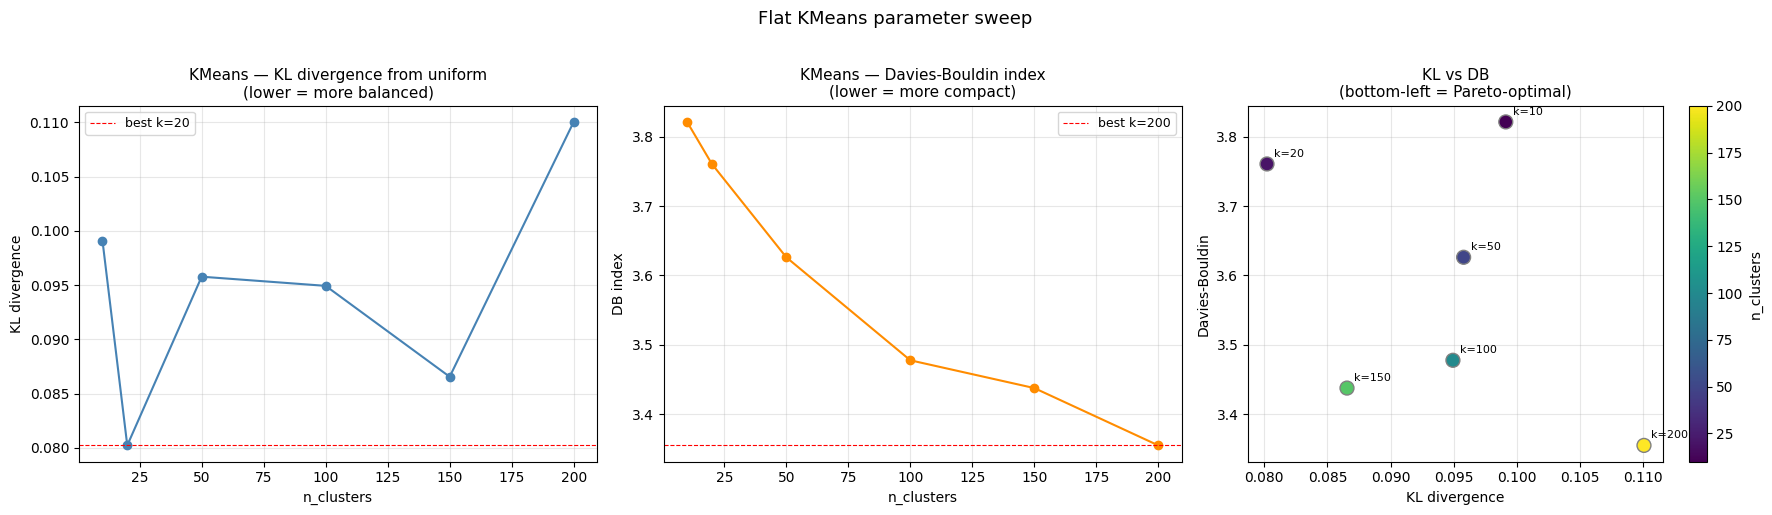

Saved → kmeans_sweep.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ks = df_km["n_clusters"].values

# KL divergence
axes[0].plot(ks, df_km["kl_divergence"], marker="o", color="steelblue")
axes[0].set_title("KMeans — KL divergence from uniform\n(lower = more balanced)", fontsize=11)
axes[0].set_xlabel("n_clusters"); axes[0].set_ylabel("KL divergence")
axes[0].axhline(df_km["kl_divergence"].min(), color="red", linestyle="--",
                linewidth=0.8, label=f"best k={df_km.loc[df_km['kl_divergence'].idxmin(),'n_clusters']}")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Davies-Bouldin
axes[1].plot(ks, df_km["davies_bouldin"], marker="o", color="darkorange")
axes[1].set_title("KMeans — Davies-Bouldin index\n(lower = more compact)", fontsize=11)
axes[1].set_xlabel("n_clusters"); axes[1].set_ylabel("DB index")
axes[1].axhline(df_km["davies_bouldin"].min(), color="red", linestyle="--",
                linewidth=0.8, label=f"best k={df_km.loc[df_km['davies_bouldin'].idxmin(),'n_clusters']}")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# KL vs DB scatter
sc = axes[2].scatter(df_km["kl_divergence"], df_km["davies_bouldin"],
                     c=ks, cmap="viridis", s=100, edgecolors="gray", zorder=3)
for _, row in df_km.iterrows():
    axes[2].annotate(f"k={int(row['n_clusters'])}",
                     xy=(row["kl_divergence"], row["davies_bouldin"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=8)
axes[2].set_xlabel("KL divergence"); axes[2].set_ylabel("Davies-Bouldin")
axes[2].set_title("KL vs DB\n(bottom-left = Pareto-optimal)", fontsize=11)
plt.colorbar(sc, ax=axes[2], label="n_clusters")
axes[2].grid(alpha=0.3)

plt.suptitle("Flat KMeans parameter sweep", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("kmeans_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → kmeans_sweep.png")

### 10.2 KMeans — cluster size distributions (top-3 by KL)

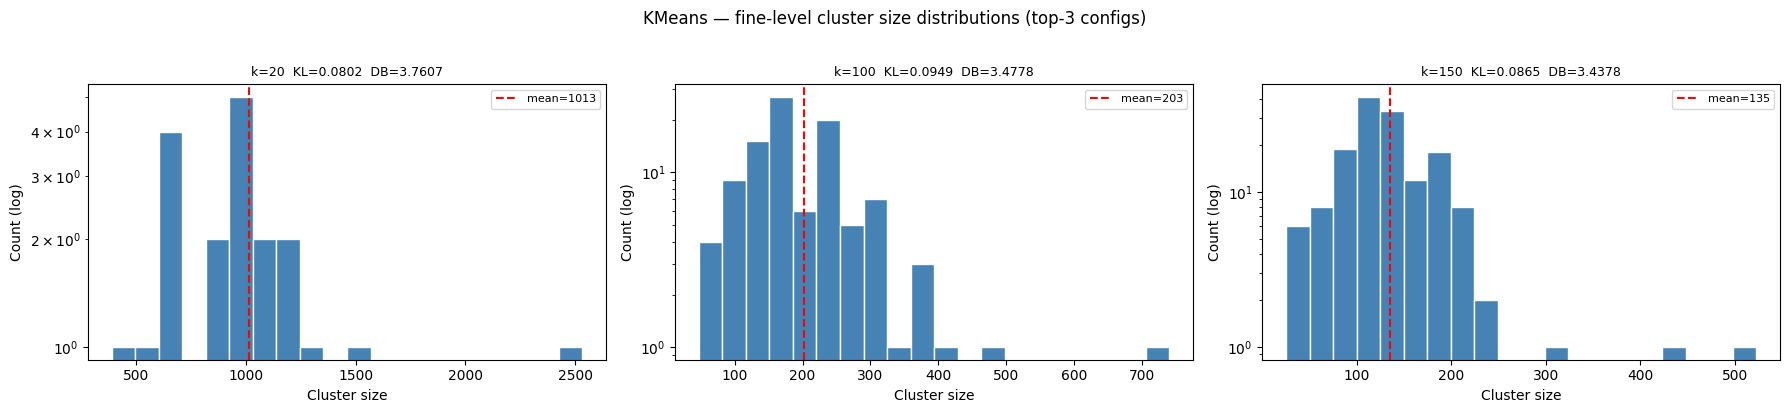

Saved → kmeans_top3_sizes.png


In [24]:
df_km_ranked = df_km.copy()
df_km_ranked["kl_norm"] = (df_km["kl_divergence"] - df_km["kl_divergence"].min()) /                            (df_km["kl_divergence"].max() - df_km["kl_divergence"].min() + 1e-9)
df_km_ranked["db_norm"] = (df_km["davies_bouldin"] - df_km["davies_bouldin"].min()) /                            (df_km["davies_bouldin"].max() - df_km["davies_bouldin"].min() + 1e-9)
df_km_ranked["combined_score"] = 0.5 * df_km_ranked["kl_norm"] + 0.5 * df_km_ranked["db_norm"]
df_km_ranked = df_km_ranked.sort_values("combined_score").reset_index(drop=True)

top3_km = df_km_ranked.head(3)["n_clusters"].astype(int).tolist()
top3_results = [r for r in kmeans_results if r["n_clusters"] in top3_km][:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, res in zip(axes, top3_results):
    sizes = np.bincount(res["labels"])
    ax.hist(sizes, bins=20, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    ax.axvline(sizes.mean(), color="red", linestyle="--", label=f"mean={sizes.mean():.0f}")
    kl_val = df_km.loc[df_km["n_clusters"] == res["n_clusters"], "kl_divergence"].values[0]
    db_val = df_km.loc[df_km["n_clusters"] == res["n_clusters"], "davies_bouldin"].values[0]
    ax.set_title(f"k={res['n_clusters']}  KL={kl_val:.4f}  DB={db_val:.4f}", fontsize=9)
    ax.set_xlabel("Cluster size"); ax.set_ylabel("Count (log)")
    ax.legend(fontsize=8)

plt.suptitle("KMeans — fine-level cluster size distributions (top-3 configs)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("kmeans_top3_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → kmeans_top3_sizes.png")

### 10.3 DBSCAN — KL & DB heatmaps over (eps, min_samples)

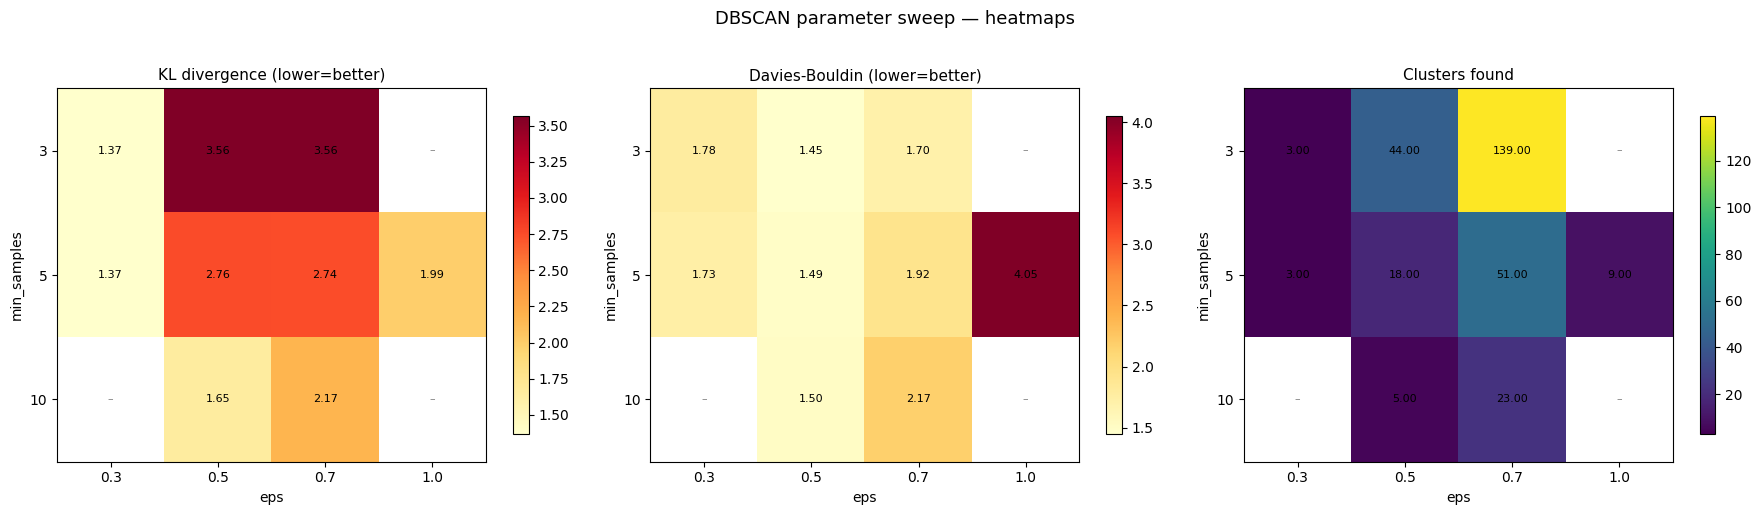

Saved → dbscan_sweep_heatmap.png


In [25]:
if len(dbscan_results) > 0:
    eps_vals = sorted(df_db["eps"].unique())
    ms_vals  = sorted(df_db["min_samples"].unique())

    def make_heatmap_matrix(metric):
        mat = np.full((len(ms_vals), len(eps_vals)), np.nan)
        for _, row in df_db.iterrows():
            i = ms_vals.index(row["min_samples"])
            j = eps_vals.index(row["eps"])
            mat[i, j] = row[metric]
        return mat

    kl_mat = make_heatmap_matrix("kl_divergence")
    db_mat = make_heatmap_matrix("davies_bouldin")
    nc_mat = make_heatmap_matrix("n_clusters")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, mat, title, cmap in [
        (axes[0], kl_mat,  "KL divergence (lower=better)",  "YlOrRd"),
        (axes[1], db_mat,  "Davies-Bouldin (lower=better)", "YlOrRd"),
        (axes[2], nc_mat,  "Clusters found",                "viridis"),
    ]:
        im = ax.imshow(mat, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(eps_vals)));   ax.set_xticklabels([str(e) for e in eps_vals])
        ax.set_yticks(range(len(ms_vals)));    ax.set_yticklabels([str(m) for m in ms_vals])
        ax.set_xlabel("eps"); ax.set_ylabel("min_samples")
        ax.set_title(title, fontsize=11)
        plt.colorbar(im, ax=ax, shrink=0.85)
        # Annotate cells
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                if not np.isnan(mat[i, j]):
                    ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center",
                            fontsize=8, color="black")
                else:
                    ax.text(j, i, "–", ha="center", va="center", fontsize=8, color="gray")

    plt.suptitle("DBSCAN parameter sweep — heatmaps", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("dbscan_sweep_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → dbscan_sweep_heatmap.png")
else:
    print("No valid DBSCAN configurations found — adjust the grid.")

### 10.4 UMAP — best KMeans vs best DBSCAN (side-by-side)

/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_87146/4172373502.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


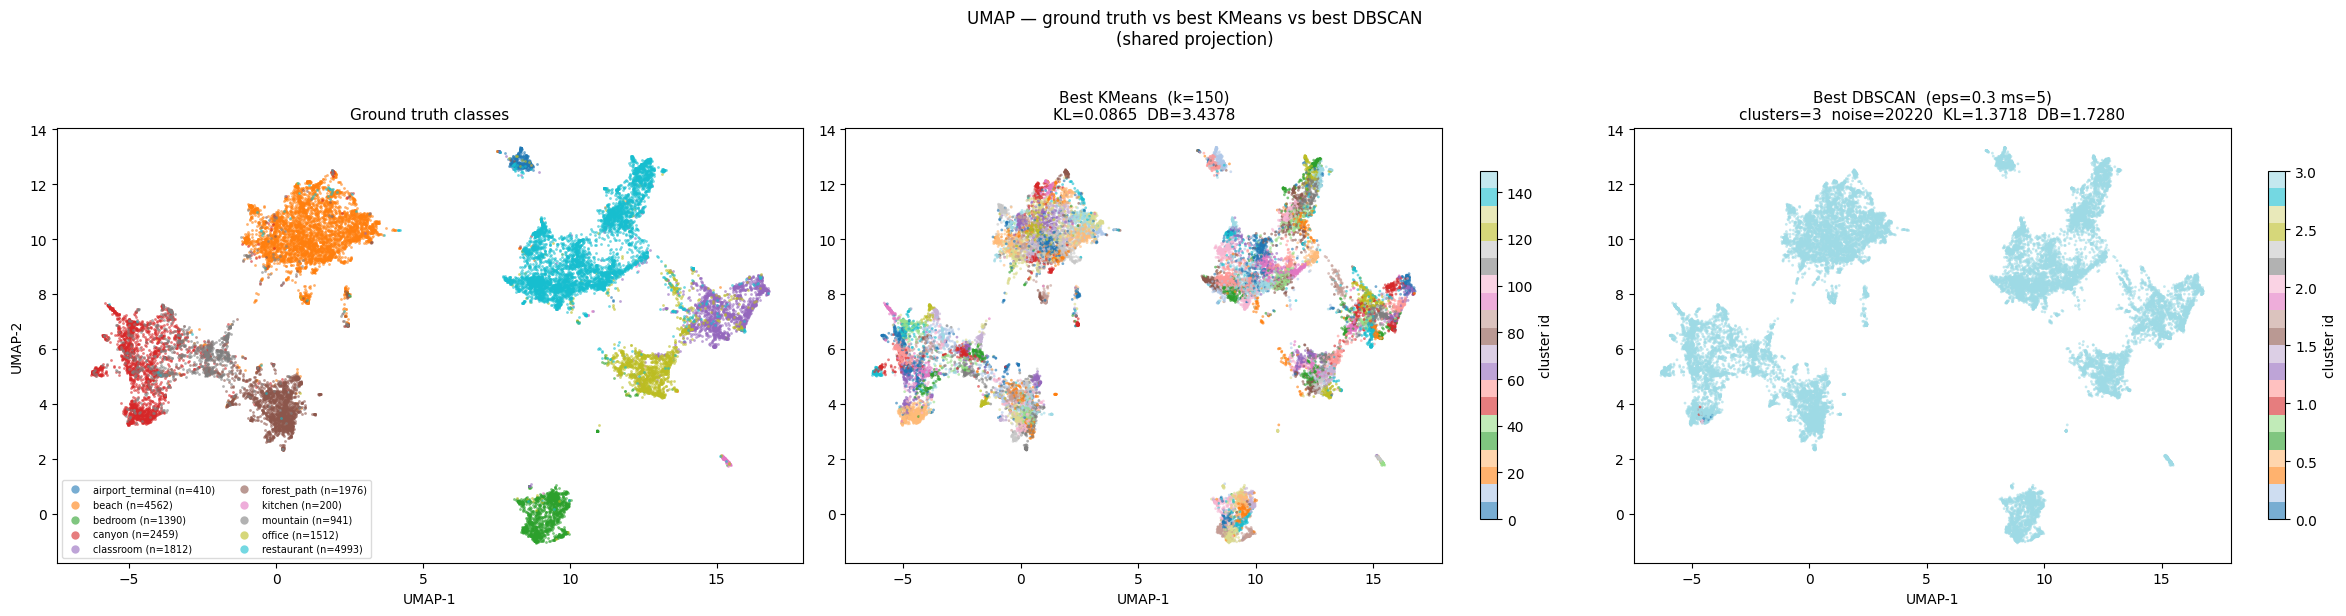

Saved → umap_kmeans_dbscan_comparison.png


In [26]:
# Pick best config for each method by combined score
best_km_row  = df_km_ranked.iloc[0]
best_km_k    = int(best_km_row["n_clusters"])
best_km_labels = next(r["labels"] for r in kmeans_results if r["n_clusters"] == best_km_k)

if len(dbscan_results) > 0:
    df_db_ranked = df_db.copy()
    df_db_ranked["kl_norm"] = (df_db["kl_divergence"] - df_db["kl_divergence"].min()) /                                (df_db["kl_divergence"].max() - df_db["kl_divergence"].min() + 1e-9)
    df_db_ranked["db_norm"] = (df_db["davies_bouldin"] - df_db["davies_bouldin"].min()) /                                (df_db["davies_bouldin"].max() - df_db["davies_bouldin"].min() + 1e-9)
    df_db_ranked["combined_score"] = 0.5 * df_db_ranked["kl_norm"] + 0.5 * df_db_ranked["db_norm"]
    df_db_ranked = df_db_ranked.sort_values("combined_score").reset_index(drop=True)
    best_db_row = df_db_ranked.iloc[0]
    best_db_labels = next(r["labels"] for r in dbscan_results
                          if r["eps"] == best_db_row["eps"]
                          and r["min_samples"] == best_db_row["min_samples"])
    n_panels = 3
else:
    n_panels = 2

# emb_2d is reused from the UMAP computed in section 9
fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 6))

# True classes (left)
class_cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)
for cls_id in range(NUM_CLASSES):
    mask = true_labels == cls_id
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=[class_cmap(cls_id)], s=4, alpha=0.6, linewidths=0,
                    label=f"{SYNSET_NAMES[cls_id]} (n={mask.sum()})")
axes[0].set_title("Ground truth classes", fontsize=11)
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=3, fontsize=7, loc="best", ncol=2, framealpha=0.7)

# Best KMeans (middle)
sc_km = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1],
                         c=best_km_labels, cmap="tab20", s=4, alpha=0.6, linewidths=0)
axes[1].set_title(
    f"Best KMeans  (k={best_km_k})\n"
    f"KL={best_km_row['kl_divergence']:.4f}  DB={best_km_row['davies_bouldin']:.4f}",
    fontsize=11)
axes[1].set_xlabel("UMAP-1")
plt.colorbar(sc_km, ax=axes[1], label="cluster id", shrink=0.8)

# Best DBSCAN (right)
if n_panels == 3:
    sc_db = axes[2].scatter(emb_2d[:, 0], emb_2d[:, 1],
                             c=best_db_labels, cmap="tab20", s=4, alpha=0.6, linewidths=0)
    axes[2].set_title(
        f"Best DBSCAN  (eps={best_db_row['eps']} ms={int(best_db_row['min_samples'])})\n"
        f"clusters={int(best_db_row['n_clusters'])}  "
        f"noise={int(best_db_row['n_noise'])}  "
        f"KL={best_db_row['kl_divergence']:.4f}  DB={best_db_row['davies_bouldin']:.4f}",
        fontsize=11)
    axes[2].set_xlabel("UMAP-1")
    plt.colorbar(sc_db, ax=axes[2], label="cluster id", shrink=0.8)

plt.suptitle("UMAP — ground truth vs best KMeans vs best DBSCAN\n(shared projection)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("umap_kmeans_dbscan_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → umap_kmeans_dbscan_comparison.png")

### 10.5 Three-way metric comparison — Hierarchical k-means vs KMeans vs DBSCAN

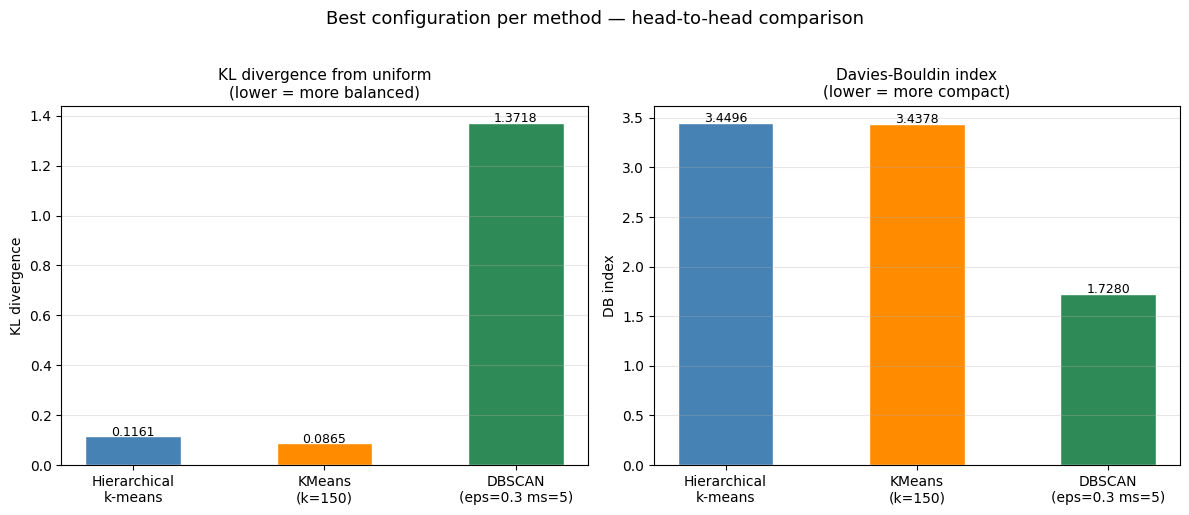

Saved → method_comparison.png


In [27]:
# Collect best scores from each method
methods, kl_scores, db_scores = [], [], []

# Hierarchical k-means (already computed in section 7)
hkm_best = df_ranked.iloc[0]
methods.append("Hierarchical\nk-means"); kl_scores.append(hkm_best["kl_divergence"]); db_scores.append(hkm_best["davies_bouldin"])

# Flat KMeans
methods.append(f"KMeans\n(k={best_km_k})"); kl_scores.append(best_km_row["kl_divergence"]); db_scores.append(best_km_row["davies_bouldin"])

# DBSCAN (if any valid config found)
if len(dbscan_results) > 0:
    methods.append(f"DBSCAN\n(eps={best_db_row['eps']} ms={int(best_db_row['min_samples'])})"); kl_scores.append(best_db_row["kl_divergence"]); db_scores.append(best_db_row["davies_bouldin"])

x   = np.arange(len(methods))
w   = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["steelblue", "darkorange", "seagreen"]

axes[0].bar(x, kl_scores, color=colors[:len(methods)], edgecolor="white", width=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(methods, fontsize=10)
axes[0].set_title("KL divergence from uniform\n(lower = more balanced)", fontsize=11)
axes[0].set_ylabel("KL divergence")
for i, v in enumerate(kl_scores):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x, db_scores, color=colors[:len(methods)], edgecolor="white", width=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(methods, fontsize=10)
axes[1].set_title("Davies-Bouldin index\n(lower = more compact)", fontsize=11)
axes[1].set_ylabel("DB index")
for i, v in enumerate(db_scores):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Best configuration per method — head-to-head comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → method_comparison.png")